In [2]:
import bioframe
import bbi
import pandas as pd
from scipy.stats import pearsonr

Ins scores

In [4]:
RESOLUTION=10000

In [5]:
ins_df = pd.read_csv("/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv")
ins_df

,chrom,start,end,region,is_bad_bin,log2_insulation_score_100000,n_valid_pixels_100000,log2_insulation_score_250000,n_valid_pixels_250000,log2_insulation_score_500000,...,log2_insulation_score_1000000,n_valid_pixels_1000000,boundary_strength_100000,boundary_strength_500000,boundary_strength_1000000,boundary_strength_250000,is_boundary_100000,is_boundary_250000,is_boundary_500000,is_boundary_1000000
0,chr1,0,10000,chr1,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
1,chr1,10000,20000,chr1,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
2,chr1,20000,30000,chr1,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
3,chr1,30000,40000,chr1,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
4,chr1,40000,50000,chr1,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303109,chrX,156000000,156010000,chrX,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
303110,chrX,156010000,156020000,chrX,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
303111,chrX,156020000,156030000,chrX,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
303112,chrX,156030000,156040000,chrX,True,NaN,0.0,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False


atacseq

In [ ]:
atacseq_bws = [
    '/home/carlos/Clone/ctcf_xpc/atac_seq/GSM7089925_ATACseq_WT_noUV_Rep1.bw',
    '/home/carlos/Clone/ctcf_xpc/atac_seq/GSM7089926_ATACseq_WT_noUV_Rep2.bw'
]

atacdf = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
for i, bw in enumerate(atacseq_bws):
    stackup = bbi.stackup(bw, atacdf.chrom, atacdf.start, atacdf.end, bins=1, summary='sum')
    atacdf[f'ATACseq_{i+1}'] = stackup

atacdf['atac_mean'] = atacdf[['ATACseq_1', 'ATACseq_2']].mean(axis=1)
# atacdf.to_csv(f"WTnoUV_atacseq_{RESOLUTION}bp.csv", index=False)    


In [ ]:
atacdf[['ATACseq_1', 'ATACseq_2']] = atacdf[['ATACseq_1', 'ATACseq_2']].fillna(0)
pearsonr(atacdf['ATACseq_1'], atacdf['ATACseq_2'])

loops

In [ ]:
dots_df = pd.read_csv("/home/carlos/Clone/ggner-3d/data/dots/dots_WTnoUV_10000.csv")

In [ ]:
df = dots_df.loc[:, ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']]

df1 = df[['chrom1', 'start1', 'end1']].rename(columns={'chrom1':'chrom', 'start1':'start', 'end1':'end'})
df2 = df[['chrom2', 'start2', 'end2']].rename(columns={'chrom2':'chrom', 'start2':'start', 'end2':'end'})
regions = pd.concat([df1, df2], ignore_index=True)

# Sort by chrom and start
regions = regions.sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

# Group by chromosome and merge overlapping or adjacent intervals
merged = []
for chrom, group in regions.groupby('chrom', sort=False):
    starts = group['start'].values
    ends = group['end'].values

    # initialize first interval
    cur_start, cur_end = starts[0], ends[0]
    for s, e in zip(starts[1:], ends[1:]):
        if s <= cur_end:  # overlap or adjacency
            cur_end = max(cur_end, e)
        else:
            merged.append((chrom, cur_start, cur_end))
            cur_start, cur_end = s, e
    merged.append((chrom, cur_start, cur_end))

# Convert merged list to DataFrame
unique_regions = pd.DataFrame(merged, columns=['chrom', 'start', 'end']).drop_duplicates().reset_index(drop=True)

anchors_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
anchors_df = bioframe.count_overlaps(anchors_df, unique_regions)
anchors_df['looped'] = anchors_df['count'] > 0

# anchors_df[['chrom', 'start', 'end', 'looped']].to_csv(f"WTnoUV_looped_{RESOLUTION}bp.csv", index=False)

n ctcf peaks

In [10]:
bins = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
ctcf_wt_peaks = pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/WT_NoUV_idr_conservative_merged.narrowPeak', sep='\t', header=None)
ctcf_wt_peaks = ctcf_wt_peaks.loc[ctcf_wt_peaks[4] >= 540][[0,1,2]].rename(columns={0: 'chrom', 1: 'start', 2: 'end'})

ctcf_peaks_df = bioframe.count_overlaps(bins, ctcf_wt_peaks)
# ctcf_peaks_df.to_csv(f"WTnoUV_ctcf_peaks_{RESOLUTION}bp.csv", index=False)

ctcf_wt_peaks = pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/WT_NoUV_idr_conservative_merged.narrowPeak', sep='\t', header=None)
ctcf_wt_peaks = ctcf_wt_peaks.loc[ctcf_wt_peaks[4] >= 540]

NARROWPEAK_COLS = [
    "chrom", "chromStart", "chromEnd", "name", "score",
    "strand", "signalValue", "pValue", "qValue", "peak"
]

def df_to_narrowpeak(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert a pandas DataFrame that may have extra IDR/replicate columns
    into a regular 10-column narrowPeak DataFrame.
    - If df already has the standard column names, it selects them.
    - Otherwise it assumes the first 10 columns are narrowPeak-like (common for IDR output).
    """
    # 1) Select narrowPeak columns (by name if possible, else by position)
    if set(NARROWPEAK_COLS).issubset(df.columns):
        out = df.loc[:, NARROWPEAK_COLS].copy()
    else:
        if df.shape[1] < 10:
            raise ValueError(f"Need at least 10 columns to form narrowPeak, got {df.shape[1]}")
        out = df.iloc[:, :10].copy()
        out.columns = NARROWPEAK_COLS

    # 2) Coerce types + basic cleanup
    out["chromStart"] = pd.to_numeric(out["chromStart"], errors="coerce").fillna(0).astype("int64")
    out["chromEnd"]   = pd.to_numeric(out["chromEnd"],   errors="coerce").fillna(0).astype("int64")

    # name: fill if missing
    out["name"] = out["name"].fillna(
        out["chrom"].astype(str) + ":" + out["chromStart"].astype(str) + "-" + out["chromEnd"].astype(str)
    ).astype(str)

    # score should be int 0..1000 for BED score
    out["score"] = pd.to_numeric(out["score"], errors="coerce").fillna(0)
    out["score"] = out["score"].round().clip(0, 1000).astype("int64")

    # strand is often '.' for narrowPeak
    out["strand"] = out["strand"].fillna(".").astype(str)

    # signal/p/q can be floats; keep as numeric where possible
    for c in ["signalValue", "pValue", "qValue"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(-1)

    # peak: narrowPeak expects summit OFFSET from chromStart
    out["peak"] = pd.to_numeric(out["peak"], errors="coerce").fillna(-1)

    # If peak looks like an absolute genomic coordinate (common in some pipelines),
    # convert to offset when most values fall within [chromStart, chromEnd].
    valid = out["peak"].ge(out["chromStart"]) & out["peak"].le(out["chromEnd"])
    if valid.mean() > 0.9:  # heuristic: "mostly looks like coordinate"
        out.loc[valid, "peak"] = out.loc[valid, "peak"] - out.loc[valid, "chromStart"]

    out["peak"] = out["peak"].astype("int64")

    return out

np_df = df_to_narrowpeak(ctcf_wt_peaks)
np_df.to_csv("WTnoUV_ctcf_peaks_idr_thresholded.narrowPeak", sep='\t', header=False, index=False)

ctcf signal

In [ ]:
ctcf_bws = [
    '/home/carlos/Clone/ctcf_xpc/ctcf_signal/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/Clone/ctcf_xpc/ctcf_signal/WT_NoUV_REP2.mLb.clN.rpgc.bw'
]

ctcf_signal_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
for i, bw in enumerate(ctcf_bws):
    stackup = bbi.stackup(bw, ctcf_signal_df.chrom, ctcf_signal_df.start, ctcf_signal_df.end, bins=1, summary='sum')
    ctcf_signal_df[f'CTCF_{i+1}'] = stackup

ctcf_signal_df['ctcf_mean'] = ctcf_signal_df[['CTCF_1', 'CTCF_2']].mean(axis=1)
# ctcf_signal_df.to_csv(f"WTnoUV_ctcf_signal_{RESOLUTION}bp.csv", index=False)

In [ ]:
ctcf_signal_df[['CTCF_1', 'CTCF_2']] = ctcf_signal_df[['CTCF_1', 'CTCF_2']].fillna(0)
pearsonr(ctcf_signal_df['CTCF_1'], ctcf_signal_df['CTCF_2'])

xpc signal

In [ ]:
xpc_bws = [
    '/home/carlos/Clone/ctcf_xpc/xpc_signal/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/Clone/ctcf_xpc/xpc_signal/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/Clone/ctcf_xpc/xpc_signal/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw',
    '/home/carlos/Clone/ctcf_xpc/xpc_signal/XPC_WT_noUV_REP4.mLb.clN.rpgc.bw',
]

xpcdf = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
for i, bw in enumerate(xpc_bws):
    stackup = bbi.stackup(bw, xpcdf.chrom, xpcdf.start, xpcdf.end, bins=1, summary='sum')
    xpcdf[f'XPC_{i+1}'] = stackup

In [ ]:
for rep1 in ['XPC_1', 'XPC_2', 'XPC_3', 'XPC_4']:
    for rep2 in ['XPC_1', 'XPC_2', 'XPC_3', 'XPC_4']:
        if rep1 < rep2:
            r, p = pearsonr(xpcdf[rep1].fillna(0), xpcdf[rep2].fillna(0))
            print(f"{rep1} vs {rep2}: r={r:.5f}, p={p:.5e}")

In [ ]:
xpcdf['xpc_mean'] = xpcdf[['XPC_1', 'XPC_2', 'XPC_3']].mean(axis=1)
# xpcdf.to_csv(f"WTnoUV_xpc_signal_{RESOLUTION}bp.csv", index=False)

pc1

In [ ]:
cis_eigs = pd.read_csv('/home/carlos/Clone/ggner-3d/data/compartment/compartment_eigvecs_WTnoUV_100000.tsv', sep='\t')
pc1 = cis_eigs[['chrom', 'start', 'end', 'E1']]
pc1_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
pc1_df = bioframe.overlap(pc1_df, pc1)
pc1_df = pc1_df[['chrom', 'start', 'end', 'E1_']].rename(columns={'E1_':'E1'})
# pc1_df.to_csv(f"WTnoUV_pc1_100kb.csv", index=False)

cis_eigs10kb = pd.read_csv('/home/carlos/Clone/ctcf_xpc/WTnoUV_10kb.cis.vecs.tsv', sep='\t')
pc1_10kb = cis_eigs10kb[['chrom', 'start', 'end', 'E1']]
pc1_10kb_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
pc1_10kb_df = bioframe.overlap(pc1_10kb_df, pc1_10kb)
pc1_10kb_df = pc1_10kb_df[['chrom', 'start', 'end', 'E1_']].rename(columns={'E1_':'E1'})

H3K4me1

In [ ]:
h3k4me1_bws = [
    '/home/carlos/Clone/ctcf_xpc/H3K4me1/GSM8133822_H3K4me1_WT_noUV_Rep1.bw',
    '/home/carlos/Clone/ctcf_xpc/H3K4me1/GSM8133824_H3K4me1_WT_noUV_Rep2.bw',
    '/home/carlos/Clone/ctcf_xpc/H3K4me1/GSM8133826_H3K4me1_WT_noUV_Rep3.bw',
]

h3k4me1_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
for i, bw in enumerate(h3k4me1_bws):
    stackup = bbi.stackup(bw, h3k4me1_df.chrom, h3k4me1_df.start, h3k4me1_df.end, bins=1, summary='sum')
    h3k4me1_df[f'H3K4me1_{i+1}'] = stackup

In [ ]:
for rep1 in ['H3K4me1_1', 'H3K4me1_2', 'H3K4me1_3']:
    for rep2 in ['H3K4me1_1', 'H3K4me1_2', 'H3K4me1_3']:
        if rep1 < rep2:
            r, p = pearsonr(h3k4me1_df[rep1].fillna(0), h3k4me1_df[rep2].fillna(0))
            print(f"{rep1} vs {rep2}: r={r:.5f}, p={p:.5e}")

In [ ]:
h3k4me1_df['h3k4me1_mean'] = h3k4me1_df[['H3K4me1_1', 'H3K4me1_2', 'H3K4me1_3']].mean(axis=1)
#  h3k4me1_df.to_csv(f"WTnoUV_h3k4me1_signal_{RESOLUTION}bp.csv", index=False)

H3K4me3

In [ ]:
h3k4me3_bws = [
    '/home/carlos/Clone/ctcf_xpc/H3K4me3/GSM6600679_H3K4me3_WT_noUV_Rep1.bw',
    '/home/carlos/Clone/ctcf_xpc/H3K4me3/GSM6600681_H3K4me3_WT_noUV_Rep2.bw',
    '/home/carlos/Clone/ctcf_xpc/H3K4me3/GSM6600683_H3K4me3_WT_noUV_Rep3.bw',
]

h3k4me3_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
for i, bw in enumerate(h3k4me3_bws):
    stackup = bbi.stackup(bw, h3k4me3_df.chrom, h3k4me3_df.start, h3k4me3_df.end, bins=1, summary='sum')
    h3k4me3_df[f'H3K4me3_{i+1}'] = stackup

In [ ]:
for rep1 in ['H3K4me3_1', 'H3K4me3_2', 'H3K4me3_3']:
    for rep2 in ['H3K4me3_1', 'H3K4me3_2', 'H3K4me3_3']:
        if rep1 < rep2:
            r, p = pearsonr(h3k4me3_df[rep1].fillna(0), h3k4me3_df[rep2].fillna(0))
            print(f"{rep1} vs {rep2}: r={r:.5f}, p={p:.5e}")

In [ ]:
h3k4me3_df['h3k4me3_mean'] = h3k4me3_df[['H3K4me3_1', 'H3K4me3_2', 'H3K4me3_3']].mean(axis=1)
#  h3k4me3_df.to_csv(f"WTnoUV_h3k4me3_signal_{RESOLUTION}bp.csv", index=False)

H3K27ac

In [ ]:
h3k27ac_bws = [
    '/home/carlos/Clone/ctcf_xpc/H3K27ac/GSM8133846_H3K27ac_WT_noUV_Rep1.bw',
    '/home/carlos/Clone/ctcf_xpc/H3K27ac/GSM8133848_H3K27ac_WT_noUV_Rep2.bw',
    '/home/carlos/Clone/ctcf_xpc/H3K27ac/GSM8133850_H3K27ac_WT_noUV_Rep3.bw',
]

h3k27ac_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
for i, bw in enumerate(h3k27ac_bws):
    stackup = bbi.stackup(bw, h3k27ac_df.chrom, h3k27ac_df.start, h3k27ac_df.end, bins=1, summary='sum')
    h3k27ac_df[f'H3K27ac_{i+1}'] = stackup

In [ ]:
for rep1 in ['H3K27ac_1', 'H3K27ac_2', 'H3K27ac_3']:
    for rep2 in ['H3K27ac_1', 'H3K27ac_2', 'H3K27ac_3']:
        if rep1 < rep2:
            r, p = pearsonr(h3k27ac_df[rep1].fillna(0), h3k27ac_df[rep2].fillna(0))
            print(f"{rep1} vs {rep2}: r={r:.5f}, p={p:.5e}")

In [ ]:
h3k27ac_df['h3k27ac_mean'] = h3k27ac_df[['H3K27ac_1', 'H3K27ac_2', 'H3K27ac_3']].mean(axis=1)
#  h3k27ac_df.to_csv(f"WTnoUV_h3k27ac_signal_{RESOLUTION}bp.csv", index=False)

damageseq

In [ ]:
ds_path = "/home/carlos/Clone/ctcf_xpc/damageseq/WT_0h_rep2_hg38_DS.1000.rpkm.bw"
damageseq = ins_df.loc[:, ['chrom', 'start', 'end']].copy()
stackup = bbi.stackup(ds_path, damageseq.chrom, damageseq.start, damageseq.end, bins=1, summary='sum')
damageseq['damageseq'] = stackup
#  damageseq.to_csv(f"WTnoUV_damageseq_{RESOLUTION}bp.csv", index=False)

pol2

In [8]:
pol2_path = "/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"
pol2_df = ins_df.loc[:, ['chrom', 'start', 'end']].copy()


stackup = bbi.stackup(pol2_path, pol2_df.chrom, pol2_df.start, pol2_df.end, bins=1, summary='sum')
pol2_df['pol2'] = stackup
#  pol2_df.to_csv(f"WTnoUV_pol2_signal_{RESOLUTION}bp.csv", index=False)

gather all

In [ ]:
ws_ = [100_000, 1_000_000]

In [ ]:
def build_final_df(
    ins_df, ws,
    xpcdf, ctcf_signal_df, atacdf, ctcf_motif_df,
    anchors_df, ctcf_peaks_df,
    h3k4me1_df, h3k4me3_df, h3k27ac_df,
    pc1_df, damageseq, pc1_10kb_df
):
    """
    Build the unified final_df given insulation and signal dataframes.
    """

    # Select & rename insulation-related columns
    final_df = ins_df.loc[:, [
        'chrom', 'start', 'end',
        f'log2_insulation_score_{ws}',
        f'is_boundary_{ws}'
    ]].copy()

    final_df = final_df.rename(columns={
        f'log2_insulation_score_{ws}': 'log2_insulation_score',
        f'is_boundary_{ws}': 'is_boundary'
    })

    # Add additional columns
    final_df['xpc_signal']       = xpcdf['xpc_mean']
    final_df['ctcf_signal']      = ctcf_signal_df['ctcf_mean']
    final_df['atac_signal']      = atacdf['atac_mean']
    final_df['n_ctcf_motif']     = ctcf_motif_df['count']
    final_df['looped']           = anchors_df['looped']
    final_df['n_ctcf_peaks']     = ctcf_peaks_df['count']
    final_df['h3k4me1_signal']   = h3k4me1_df['h3k4me1_mean']
    final_df['h3k4me3_signal']   = h3k4me3_df['h3k4me3_mean']
    final_df['h3k27ac_signal']   = h3k27ac_df['h3k27ac_mean']
    final_df['pc1']              = pc1_df['E1']
    final_df['pc1_10kb']         = pc1_10kb_df['E1']
    final_df['damageseq']        = damageseq['damageseq']
    final_df['pol2']             = pol2_df['pol2']

    # Drop missing rows
    final_df.dropna(inplace=True)

    # Reorder columns
    final_df = final_df[[
        'chrom', 'start', 'end', 'log2_insulation_score', 'xpc_signal',
        'ctcf_signal', 'atac_signal', 'n_ctcf_motif', 'looped',
        'n_ctcf_peaks', 'is_boundary', 'h3k4me1_signal',
        'h3k4me3_signal', 'h3k27ac_signal', 'pc1', 'damageseq', 'pc1_10kb',
        'pol2'
    ]]

    return final_df

for ws in ws_:
    final_df = build_final_df(
        ins_df, ws,
        xpcdf, ctcf_signal_df, atacdf, ctcf_motif_df,
        anchors_df, ctcf_peaks_df,
        h3k4me1_df, h3k4me3_df, h3k27ac_df,
        pc1_df, damageseq, pc1_10kb_df, pol2_df
    )
    final_df.to_csv(f"WTnoUV_ws_{ws}.csv", index=False)

Visualize cutoffs

In [1]:
import pandas as pd

final_df = pd.read_csv(
    "/home/carlos/Clone/ggner-3d/src/r_scripts/WTnoUV_ws_100000_with_pol2.csv"
)

In [2]:
filtered_df = final_df.loc[final_df.n_ctcf_peaks > 0]
x = filtered_df['xpc_signal'].to_numpy()

In [3]:
x.shape

(32557,)

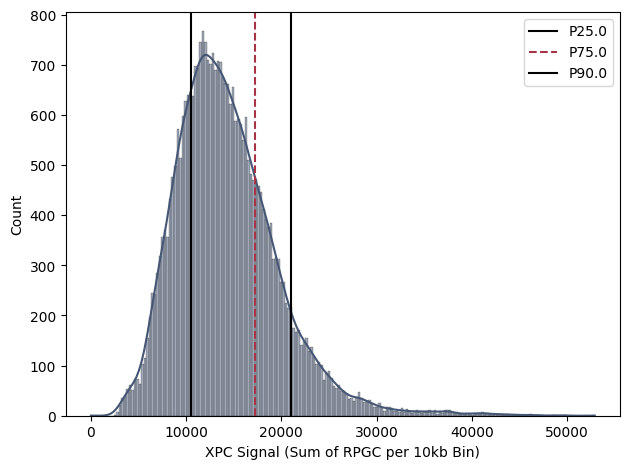

In [4]:
import numpy as np
q_lo_lo = 0.25
q_lo_hi = 0.75
q_hi_lo = 0.80
q_hi_hi = 0.90
q_lo_lo_corresponds = pd.Series(x).quantile(q_lo_lo)
q_lo_hi_corresponds = pd.Series(x).quantile(q_lo_hi)
q_hi_lo_corresponds = pd.Series(x).quantile(q_hi_lo)
q_hi_hi_corresponds = pd.Series(x).quantile(q_hi_hi)

import seaborn as sns
import matplotlib.pyplot as plt

colors = ['#465775', '#A63446', '#F5B841', '#9DBBAE']


sns.histplot(x, bins=200, kde=True, color=colors[0])

plt.axvline(q_lo_lo_corresponds, color='black', linestyle='-', label=f'P{q_lo_lo*100}')
plt.axvline(q_lo_hi_corresponds, color=colors[1], linestyle='--', label=f'P{q_lo_hi*100}')
# plt.axvline(q_hi_lo_corresponds, color=colors[1], linestyle='--', label=f'P{q_hi_lo*100}')
plt.axvline(q_hi_hi_corresponds, color='black', linestyle='-', label=f'P{q_hi_hi*100}')

plt.legend()
plt.xlabel('XPC Signal (Sum of RPGC per 10kb Bin)')
plt.ylabel(f'Count')

# highlight area where xpc_signal is smaller then q_lo_lo_corresponds
import numpy as np
plt.fill_betweenx(y=[0, plt.ylim()[1]], x1=-np.inf, x2=q_lo_lo_corresponds, color='black', alpha=0.8)
# save fig
plt.tight_layout()
plt.savefig(f"/home/carlos/Clone/ggner-3d/figs/fig4/xpc_signal_distribution_with_cutoffs.svg")